In [13]:
import random
import numpy as np
from collections import defaultdict
import albumentations as A
from pathlib import Path
from glob import glob
import os
import matplotlib.pyplot as plt
from PIL import Image

In [14]:
UAVID_CLS = [
    'Background clutter', # 0
    'Building',           # 1
    'Road',               # 2
    'Tree',               # 3
    'Low vegetation',     # 4
    'Moving car',         # 5
    'Static car',         # 6
    'Human',              # 7
]

UAVID_COLORMAP = [
    (0, 0, 0),          # Background Clutter
    (128, 0, 0),        # Building
    (128, 64, 128),     # Road
    (0, 128, 0),        # Tree
    (128, 128, 0),      # Low vegetation
    (64, 0, 128),       # Moving car
    (192, 0, 192),      # Static car
    (64, 64, 0),        # Human 
]

UAVID_PASTE_RATIO = [
    0,     # Background Clutter
    0,     # Building
    0,     # Road
    0,     # Tree
    0,     # Low vegetation
    0.25,     # Moving car
    0.25,     # Static car
    0.5,     # Human 
]

COLOR2ID = {rgb: idx for idx, rgb in enumerate(UAVID_COLORMAP)}
ID2COLOR = {idx: rgb for idx, rgb in enumerate(UAVID_COLORMAP)}

In [15]:
class CopyPaste(A.DualTransform):
    """Custom augmentation for Copy-Paste augmentation with mask support."""
    
    def __init__(self, data, num_paste=30, paste_ratio=None, instance_per_cls=10, 
                 pool_samples=20, seed=42, always_apply=False, p=1.0):
        super(CopyPaste, self).__init__(always_apply, p)
        
        random.seed(seed)
        np.random.seed(seed)

        self.data = self.convert_data(data)
        self.num_paste = num_paste
        if paste_ratio is None:
            self.paste_ratio = [0.0] * len(UAVID_CLS)
        else:
            self.paste_ratio = paste_ratio
        self.instance_per_cls = instance_per_cls
        self.object_pool = defaultdict(list)
        
        self.build_object_pool(samples=pool_samples)

    def __call__(self, force_apply=True, **kwargs):
        kwargs["image"],kwargs["mask"] = self.paste(kwargs["image"],kwargs["mask"])
        return kwargs
    
    @staticmethod
    def rgb_to_cls(mask):
        """Convert RGB mask to class indices"""
        _, h, w = mask.shape
        mapped_mask = np.zeros((h, w), dtype=np.uint8)

        for rgb, cls_id in COLOR2ID.items():
            matches = np.all(mask == np.array(rgb)[:, None, None], axis=0)
            mapped_mask[matches] = cls_id

        return mapped_mask[np.newaxis, ...].astype(np.int64)

    @staticmethod
    def cls_to_rgb(cls_mask):
        """Convert class mask to RGB"""
        _, H, W = cls_mask.shape
        rgb_mask = np.zeros((3, H, W), dtype=np.uint8)

        for cls_id, rgb in ID2COLOR.items():
            pixels = cls_mask[0] == cls_id
            for c in range(3):
                rgb_mask[c][pixels] = rgb[c]

        return rgb_mask

    @staticmethod
    def convert_data(raw_data):
        processed_data = []

        for item in raw_data:
            img = item["image"]
            if isinstance(img, str):
                img = np.array(Image.open(img).convert("RGB"))
            else:
                img = np.asarray(img, dtype=np.uint8)

            mask = item["label"]
            if isinstance(mask, str):
                mask = np.array(Image.open(mask).convert("RGB"))
            else:
                mask = np.asarray(mask, dtype=np.uint8)

            assert img.ndim == 3 and img.shape[2] == 3, f"Image must be HxWx3, got {img.shape}"
            assert mask.ndim == 3 and mask.shape[2] == 3, f"Mask must be HxWx3, got {mask.shape}"

            mask = mask.transpose(2, 0, 1)
            processed_data.append([img, mask])

        return processed_data

    def extract_obj(self, img, class_mask, class_enum, radius=200, threshold=1000):
        """Extract object from image and mask"""
        bin_mask = (class_mask[0] == class_enum).astype(np.uint8)

        ys, xs = np.where(bin_mask == 1)
        if len(ys) == 0:
            return None

        y_center = int(np.mean(ys))
        x_center = int(np.mean(xs))

        H, W = bin_mask.shape
        Y, X = np.ogrid[:H, :W]
        dist = (X - x_center)**2 + (Y - y_center)**2
        circle_mask = (dist <= radius * radius)

        obj_mask_binary = (bin_mask & circle_mask).astype(np.uint8)

        if obj_mask_binary.sum() < threshold:
            return None

        obj_img = np.zeros((H, W, 4), dtype=img.dtype)
        obj_img[:, :, :3] = img
        obj_img[:, :, 3] = obj_mask_binary * 255

        obj_mask_full = np.zeros_like(class_mask)
        obj_mask_full[0][obj_mask_binary == 1] = class_enum

        obj_mask_rgb = self.cls_to_rgb(obj_mask_full)
        obj_mask_rgb = np.transpose(obj_mask_rgb, (1, 2, 0))

        obj_mask_rgba = np.zeros((H, W, 4), dtype=obj_mask_rgb.dtype)
        obj_mask_rgba[:, :, :3] = obj_mask_rgb
        obj_mask_rgba[:, :, 3] = obj_mask_binary * 255

        ys, xs = np.where(obj_mask_binary == 1)
        ymin, ymax = ys.min(), ys.max() + 1
        xmin, xmax = xs.min(), xs.max() + 1

        obj_img_crop = obj_img[ymin:ymax, xmin:xmax]
        obj_mask_crop = obj_mask_rgba[ymin:ymax, xmin:xmax]
        #obj_img,obj_mask have (H,W,4)
        return [obj_img_crop, obj_mask_crop]

    def copy(self, img, mask):
        """Extract objects from image and add to pool"""
        class_mask = self.rgb_to_cls(mask)
        for i, cls in enumerate(UAVID_CLS):
            if i not in [5, 6, 7] or len(self.object_pool[cls]) >= self.instance_per_cls:
                continue
            obj = self.extract_obj(img, class_mask, i)
            if obj is not None:
                print(f'Added object {cls}')
                self.object_pool[cls].append(obj)

    def build_object_pool(self, samples=50):
        """Build object pool from samples"""
        copy_data = random.sample(self.data, min(samples, len(self.data)))
        for copy_img, copy_mask in copy_data:
            self.copy(copy_img, copy_mask)
        print("Pool built completed")

    def paste(self, img: np.ndarray, mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
        """Paste objects from pool onto image and mask"""
        # Input: img (H, W, 3) RGB, mask (3, H, W) or (H, W, 3)
        # Convert mask to HWC if needed
        if mask.ndim == 3 and mask.shape[0] == 3:
            mask = mask.transpose(1, 2, 0)  # (3, H, W) → (H, W, 3)

        img_to_paste = img.copy().astype(np.float32)  # (H, W, 3) RGB
        mask_to_paste = mask.copy()  # (H, W, 3) RGB

        for i, cls in enumerate(UAVID_CLS):
            num_to_paste = int(self.num_paste * self.paste_ratio[i])
            if num_to_paste == 0 or len(self.object_pool[cls]) == 0:
                continue

            for _ in range(num_to_paste):
                # Get object from pool
                obj_img, obj_mask = random.choice(self.object_pool[cls])
                # obj_img: (h_range, w_range, 4) RGBA
                # obj_mask: (h_range, w_range, 4) RGBA

                # Extract RGB and Alpha from object
                obj_rgb = obj_img[:, :, :3]  # (h_range, w_range, 3) RGB
                obj_alpha = obj_img[:, :, 3:4] / 255.0  # (h_range, w_range, 1) Alpha

                obj_mask_rgb = obj_mask[:, :, :3]  # (h_range, w_range, 3) RGB
                obj_mask_alpha = obj_mask[:, :, 3:4] / 255.0  # (h_range, w_range, 1) Alpha

                # Get object dimensions
                h_obj, w_obj = obj_rgb.shape[:2]
                h_img, w_img = img_to_paste.shape[:2]

                # Random placement
                y_start = np.random.randint(0, max(1, h_img - h_obj + 1))
                x_start = np.random.randint(0, max(1, w_img - w_obj + 1))

                # Clamp to boundaries
                y_end = min(y_start + h_obj, h_img)
                x_end = min(x_start + w_obj, w_img)

                h_clipped = y_end - y_start
                w_clipped = x_end - x_start

                if h_clipped <= 0 or w_clipped <= 0:
                    continue

                # Clip object regions
                obj_rgb_clipped = obj_rgb[:h_clipped, :w_clipped, :]  # (h_clipped, w_clipped, 3) RGB
                obj_alpha_clipped = obj_alpha[:h_clipped, :w_clipped, :]  # (h_clipped, w_clipped, 1) Alpha

                obj_mask_rgb_clipped = obj_mask_rgb[:h_clipped, :w_clipped, :]  # (h_clipped, w_clipped, 3) RGB
                obj_mask_alpha_clipped = obj_mask_alpha[:h_clipped, :w_clipped, :]  # (h_clipped, w_clipped, 1) Alpha

                # ===== Blend Image =====
                # img_region: (h_clipped, w_clipped, 3) RGB
                img_region = img_to_paste[y_start:y_end, x_start:x_end, :]

                # Blend: foreground * alpha + background * (1 - alpha)
                img_blended = obj_rgb_clipped * obj_alpha_clipped + img_region * (1 - obj_alpha_clipped)  # (h_clipped, w_clipped, 3)
                img_to_paste[y_start:y_end, x_start:x_end, :] = img_blended

                # ===== Blend Mask =====
                # mask_region: (h_clipped, w_clipped, 3) RGB
                mask_region = mask_to_paste[y_start:y_end, x_start:x_end, :]

                # Blend: foreground * alpha + background * (1 - alpha)
                mask_blended = obj_mask_rgb_clipped * obj_mask_alpha_clipped + mask_region * (1 - obj_mask_alpha_clipped)  # (h_clipped, w_clipped, 3)
                mask_to_paste[y_start:y_end, x_start:x_end, :] = mask_blended

        # Convert to output format
        img_out = img_to_paste.astype(np.uint8)  # (H, W, 3)
        mask_out = mask_to_paste.astype(np.uint8)  # (3, H, W)

        return img_out, mask_out

    def get_transform_init_args_names(self):
        return (
            "num_paste",
            "paste_ratio",
            "instance_per_cls",
            "pool_samples",
            "seed",
        )


In [16]:
ROOT = Path(os.getcwd()).parent
DATA_ROOT = ROOT / "data" / "UAVid" / "uavid_train" 

images = sorted(glob(str(DATA_ROOT / "seq*" / "Images" / "*.png")))
labels = sorted(glob(str(DATA_ROOT / "seq*" / "Labels" / "*.png")))

data = [{"image": img, "label": lbl} for img, lbl in zip(images, labels)]


In [17]:
# # Use with albumentations composition
transform = A.Compose([
    CopyPaste(
        data=random.sample(data, 50),
        num_paste=30,
        paste_ratio=UAVID_PASTE_RATIO,
        instance_per_cls=5,
        pool_samples=20,
    ),
    A.HorizontalFlip(p=0.5),
], keypoint_params=A.KeypointParams(format='xy'))
# # Apply to image and mask
# transformed = transform(image=images, mask=labels)
# aug_img = transformed['image']
# aug_mask = transformed['mask']

Added object Human
Added object Moving car
Added object Static car
Added object Moving car
Added object Static car
Added object Moving car
Added object Static car
Added object Moving car
Added object Static car
Added object Static car
Added object Human
Added object Moving car
Added object Human
Pool built completed


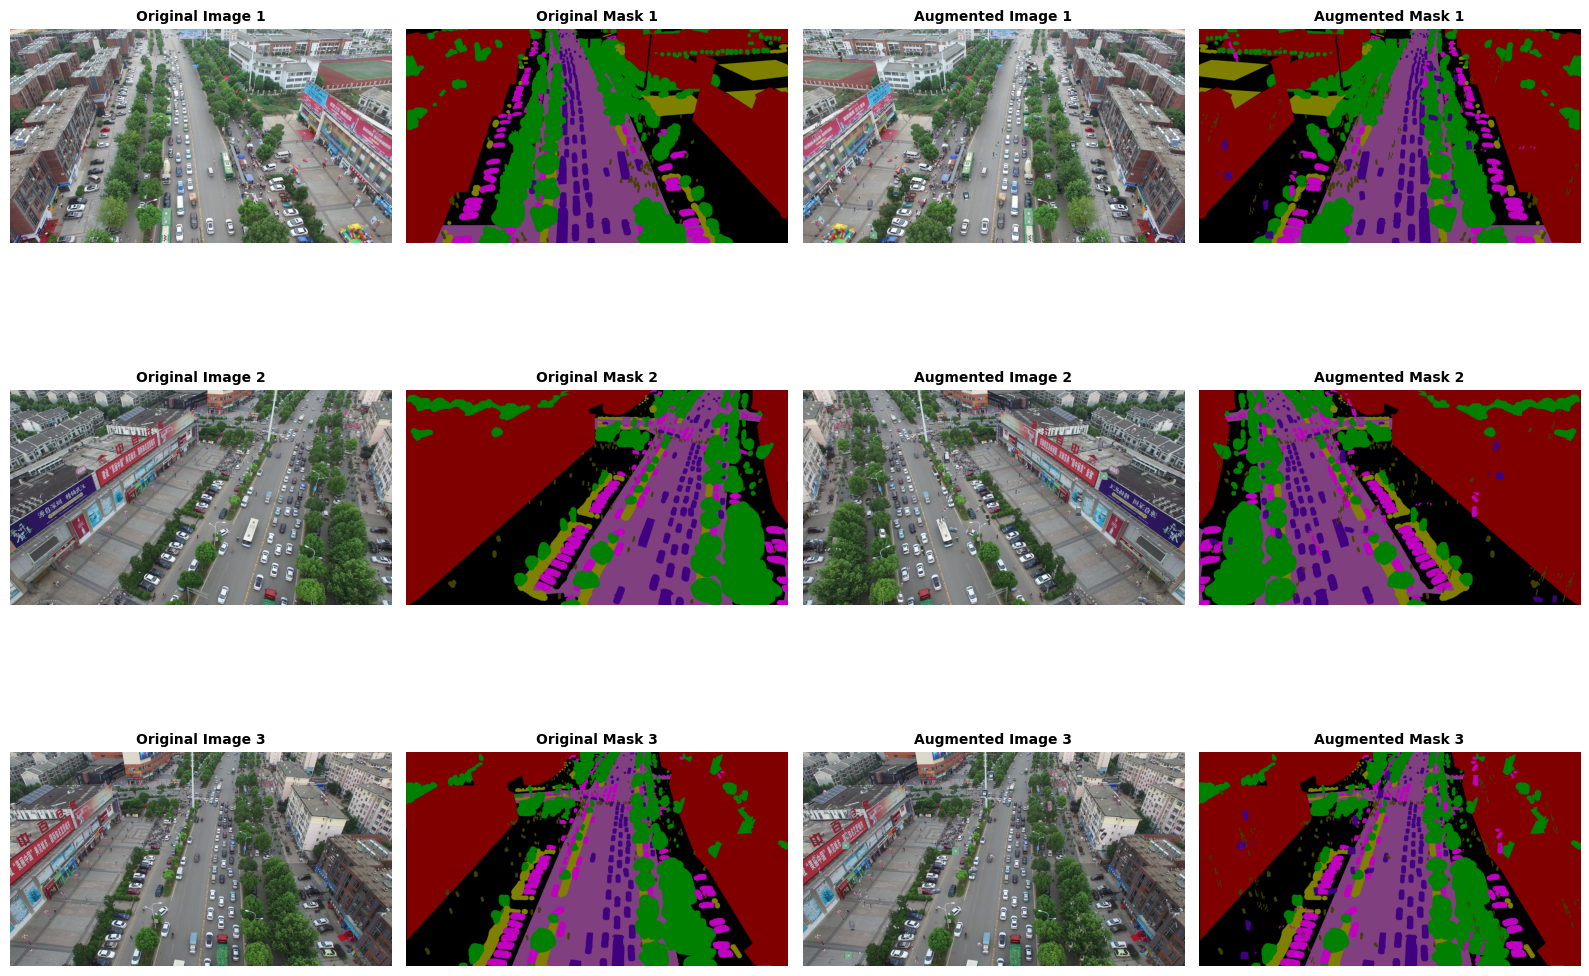

In [18]:
def display_transform(images, labels, transform, num_samples=2, figsize=(15, 10)):
    """
    Display before and after augmentation for multiple samples.
    
    Args:
        images: List of image file paths or numpy arrays
        labels: List of label/mask file paths or numpy arrays
        transform: Albumentations transform (A.Compose)
        num_samples: Number of samples to display
        figsize: Figure size (width, height)
    """
    num_samples = min(num_samples, len(images))
    
    fig, axes = plt.subplots(num_samples, 4, figsize=figsize)
    
    # Handle single sample case
    if num_samples == 1:
        axes = axes.reshape(1, -1)
    
    for idx in range(num_samples):
        # Load image
        image = images[idx]
        if isinstance(image, str):
            image = np.array(Image.open(image).convert("RGB"))
        else:
            image = np.asarray(image, dtype=np.uint8)
        
        # Load mask
        mask = labels[idx]
        if isinstance(mask, str):
            mask = np.array(Image.open(mask).convert("RGB"))
        else:
            mask = np.asarray(mask, dtype=np.uint8)
        # Mask (HWC)
        # Image (HWC)
        # Apply transform
        transformed = transform(image=image, mask=mask)
        aug_img = transformed['image']
        aug_mask = transformed['mask']
        # Display original image
        axes[idx, 0].imshow(image)
        axes[idx, 0].set_title(f"Original Image {idx+1}", fontsize=10, fontweight='bold')
        axes[idx, 0].axis('off')
        
        # Display original mask
        axes[idx, 1].imshow(mask)
        axes[idx, 1].set_title(f"Original Mask {idx+1}", fontsize=10, fontweight='bold')
        axes[idx, 1].axis('off')
        
        # Display augmented image
        axes[idx, 2].imshow(aug_img)
        axes[idx, 2].set_title(f"Augmented Image {idx+1}", fontsize=10, fontweight='bold')
        axes[idx, 2].axis('off')
        
        # Display augmented mask
        axes[idx, 3].imshow(aug_mask)
        axes[idx, 3].set_title(f"Augmented Mask {idx+1}", fontsize=10, fontweight='bold')
        axes[idx, 3].axis('off')
    
    plt.tight_layout()
    plt.show()

# Display before/after for 3 samples
display_transform(images, labels, transform, num_samples=3, figsize=(16, 12))